###Import Statements

In [1]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import ast
import json
import csv


In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
### --- Load Dataset (JSON version) --- ###
dataset_path = "/content/drive/MyDrive/Dissertation Work/Research Work/Datasets/small_circuits.json"

# Load JSON into DataFrame
with open(dataset_path, "r") as f:
    data = json.load(f)

df_circuits = pd.DataFrame(data)

# Ensure numvars is int (if missing, infer from variables length)
if "numvars" in df_circuits.columns:
    df_circuits["numvars"] = df_circuits["numvars"].astype(int)
else:
    df_circuits["numvars"] = df_circuits["variables"].apply(len)

# Quick sanity print
for _, row in df_circuits.iterrows():
    print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

3_17_13 3 6
4_49_17 4 12
alu-v0_26 5 6
graycode6_47 6 5
hwb4_51 4 11
mod5d1_63 5 7
rd32-v0_66 4 4
4gt12-v0_86 5 14
one-two-three-v0_97 5 11
ham3_102 3 5
cycle10_2_110 12 19
sys6-v0_144 10 12
cnt3-5_180 16 20


In [4]:
# # Ensure numvars is int
# if "numvars" in df_circuits.columns:
#     df_circuits["numvars"] = df_circuits["numvars"].astype(int)
# else:
#     # Fallback if column missing: infer from variables length
#     df_circuits["numvars"] = df_circuits["variables"].apply(len)

# # Quick sanity print
# for _, row in df_circuits.iterrows():
#     print(row["circuit_name"], len(row["variables"]), len(row["gates"]))

###Functions for fault model simulation and fault detection

In [5]:
def simulate_with_dp(circuit, vec, dp_table, start=0, end=None):
    if end is None:
        end = len(circuit)
    key = (id(circuit), tuple(vec), start, end)
    if key in dp_table:
        return dp_table[key]

    if end - start == 0:
        out = vec.copy()
    elif end - start == 1:
        v = vec.copy()
        gate = circuit[start]
        gtype = gate[0]
        if gtype == "TOFFOLI":
            controls, target = gate[1], gate[2]
            if all(v[c] == 1 for c in controls):
                v[target] ^= 1
        elif gtype == "FREDKIN":
            controls_list, s1, s2 = gate[1]
            if all(v[c] == 1 for c in controls_list):
                v[s1], v[s2] = v[s2], v[s1]
        out = v
    else:
        mid = (start + end) // 2
        left_out = simulate_with_dp(circuit, vec, dp_table, start, mid)
        right_out = simulate_with_dp(circuit, left_out, dp_table, mid, end)
        out = right_out

    dp_table[key] = out
    return out

In [6]:
def generate_fault_list_with_types(circuit, n_inputs):
    fault_list = []
    # Single Missing Gate Faults (SMGF)
    for i in range(len(circuit)):
        faulty_circuit = circuit[:i] + circuit[i+1:]
        fault_list.append({
            "id": f"SMGF_{i}",
            "type": "SMGF",
            "location": i,
            "circuit": faulty_circuit
        })
    return fault_list

In [7]:
def detect_fault(dp_detect, vector, fault, circuit, normal_cache):
    vkey = tuple(vector)
    if vkey not in normal_cache:
        normal_cache[vkey] = simulate_with_dp(circuit, vector.copy(), {})
    normal_output = normal_cache[vkey]

    fault_id = fault["id"]
    key = (vkey, fault_id)
    if key in dp_detect:
        return dp_detect[key]

    if fault["type"] == "SMGF":
        faulty_output = simulate_with_dp(fault["circuit"], vector.copy(), {})
    else:
        raise ValueError(f"Unknown fault type: {fault['type']}")

    detected = normal_output != faulty_output
    dp_detect[key] = detected
    return detected


###Fitness Calulation

In [8]:
def compute_fitness(individual, fault_list, circuit, dp_detect, alpha=100, beta=0.01):
    detected_faults = set()
    normal_cache = {}
    for vec in individual:
        for fault in fault_list:
            if detect_fault(dp_detect, list(vec), fault, circuit, normal_cache):
                detected_faults.add(fault["id"])
    coverage = len(detected_faults) / len(fault_list) if fault_list else 0.0
    if coverage < 1.0:
        fitness = alpha * coverage
    else:
        fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults

###Mutation and Crossover

In [9]:
def crossover(parent1, parent2):
    if len(parent1) < 2 or len(parent2) < 2:
        return [tuple(v) for v in parent1]
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    child = parent1[:cut1] + parent2[cut2:]
    return [tuple(v) for v in child]

def mutate(individual, mutation_rate=0.2):
    new_ind = []
    for vec in individual:
        if random.random() < mutation_rate:
            vlist = list(vec)
            bit = random.randint(0, len(vlist) - 1)
            vlist[bit] ^= 1
            new_ind.append(tuple(vlist))
        else:
            new_ind.append(tuple(vec))
    return new_ind

In [10]:
def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp_detect = {}
    normal_cache = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fault in fault_list:
            if fault["id"] not in covered and detect_fault(dp_detect, list(vec), fault, circuit, normal_cache):
                covered.add(fault["id"])
        if temp != covered:
            reduced.append(vec)
    return reduced


###GA+DP Approach

In [11]:
def run_ga(circuit, n_inputs, generations=100, pop_size=20, max_vecs=50, runs=5):
    fault_list = generate_fault_list_with_types(circuit, n_inputs)
    best_results = []

    for _ in range(runs):
        dp_detect = {}
        normal_cache = {}

        def random_vector():
            return tuple(random.randint(0,1) for _ in range(n_inputs))

        # Initial population
        population = []
        for _ in range(pop_size):
            k = random.randint(2, max_vecs)
            individual = [random_vector() for _ in range(k)]
            population.append(individual)

        best_cov = 0
        no_improve = 0

        for gen in range(generations):
            fitness_scores = [compute_fitness(ind, fault_list, circuit, dp_detect) for ind in population]
            population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda z: z[0][0], reverse=True)]
            best_fit, best_cov_gen, _ = fitness_scores[0]

            if best_cov_gen > best_cov:
                best_cov = best_cov_gen
                no_improve = 0
            else:
                no_improve += 1

            if best_cov == 1.0 or no_improve > 10:
                break

            next_gen = [population[0]]  # elitism
            while len(next_gen) < pop_size:
                p1, p2 = random.sample(population[:pop_size // 2], 2)
                child = crossover(p1, p2)
                child = mutate(child)
                next_gen.append(child)
            population = next_gen

        best = max(population, key=lambda ind: compute_fitness(ind, fault_list, circuit, dp_detect)[0])
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp_detect)

        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))

    return best_results

###Run over the benchmark circuits

In [12]:
def convert_dataset_gates(dataset_gates, variables):
    if isinstance(variables, str):
        variables = ast.literal_eval(variables)

    var_map = {v: i for i, v in enumerate(variables)}
    circuit = []

    for g in dataset_gates:
        if not isinstance(g, dict) or "gate" not in g or "vars" not in g:
            continue
        gate_name = str(g["gate"]).lower()
        names = g["vars"]
        idxs = [var_map[n] for n in names if n in var_map]
        if len(idxs) == 0:
            continue

        if gate_name.startswith('t'):
            if len(idxs) == 1:
                controls, target = [], idxs[0]
            else:
                controls, target = idxs[:-1], idxs[-1]
            circuit.append(("TOFFOLI", controls, target))
        elif gate_name.startswith('f'):
            if len(idxs) < 2:
                continue
            controls = idxs[:-2]
            s1, s2 = idxs[-2], idxs[-1]
            circuit.append(("FREDKIN", (controls, s1, s2)))

    return circuit

In [13]:
def run_on_dataset(df, save_csv_path="ga_results.csv"):
    results = []
    for _, row in df.iterrows():
        variables = row["variables"]
        circuit = convert_dataset_gates(row["gates"], variables)
        n_inputs = int(row["numvars"])
        if not circuit:
            print(f"⚠️ {row['circuit_name']} skipped.")
            continue
        start_time = time.time()
        best_runs = run_ga(circuit, n_inputs)
        end_time = time.time()
        execution_time = round(end_time - start_time, 2)

        best_test_set, (fitness, coverage, total_faults, detected_faults) = max(
            best_runs, key=lambda x: x[1][0]
        )
        results.append({
            "file": row['circuit_name'],
            "fitness": round(fitness, 4),
            "coverage": round(coverage, 4),
            "total_faults": total_faults,
            "detected_faults": len(detected_faults),
            "test_vectors": best_test_set,
            "num_test_vectors": len(best_test_set),
            "num_gates": len(circuit),
            "exec_time_sec": execution_time
        })

    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=["file","fitness","coverage","total_faults","detected_faults","num_test_vectors","num_gates","exec_time_sec"])
        writer.writeheader()
        for row in results:
            writer.writerow({key: row[key] for key in writer.fieldnames})
    return results

###Visualiza the Results

In [14]:
def plot_gates_coverage_vectors(results):
    files = [r["file"] for r in results]
    num_gates = [r["num_gates"] for r in results]
    coverage = [r["coverage"] for r in results]
    num_vectors = [r["num_test_vectors"] for r in results]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))
    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()
    plt.show()


def plot_coverage_vs_vectors(results):
    x = [r["num_test_vectors"] for r in results]
    y = [r["coverage"] for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, s=100)
    for i, label in enumerate(labels):
        plt.text(x[i] + 0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_efficiency(results):
    efficiency = [(r["detected_faults"] / r["num_test_vectors"]) if r["num_test_vectors"] else 0 for r in results]
    labels = [r["file"] for r in results]
    plt.figure(figsize=(10, 5))
    plt.bar(labels, efficiency)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

In [15]:
# Run GA + DP on the dataset
results = run_on_dataset(df_circuits, save_csv_path="/content/drive/MyDrive/Dissertation Work/Research Work/Results/small_smgf.csv")

In [16]:
def plot_faults_per_circuit(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    files = [r["file"] for r in filtered]
    total_faults = [r["total_faults"] for r in filtered]
    detected_faults = [r["detected_faults"] for r in filtered]

    x = np.arange(len(files))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    bar1 = ax.bar(x - width/2, total_faults, width, label="Total Faults", color='lightgray')
    bar2 = ax.bar(x + width/2, detected_faults, width, label="Detected Faults", color='mediumseagreen')

    ax.set_xlabel("Circuit")
    ax.set_ylabel("Number of Faults")
    ax.set_title("Total vs Detected Faults per Circuit")
    ax.set_xticks(x)
    ax.set_xticklabels(files, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y')

    plt.tight_layout()
    plt.show()


In [17]:
for r in results:
    print(f'{r["file"]} → gates: {r.get("num_gates")}, vectors: {r.get("num_test_vectors")}, time: {r.get("exec_time_sec")} sec')



3_17_13 → gates: 6, vectors: 2, time: 0.05 sec
4_49_17 → gates: 12, vectors: 3, time: 0.14 sec
alu-v0_26 → gates: 6, vectors: 3, time: 0.09 sec
graycode6_47 → gates: 5, vectors: 2, time: 0.1 sec
hwb4_51 → gates: 11, vectors: 2, time: 0.13 sec
mod5d1_63 → gates: 7, vectors: 2, time: 0.1 sec
rd32-v0_66 → gates: 4, vectors: 3, time: 0.04 sec
4gt12-v0_86 → gates: 14, vectors: 4, time: 0.24 sec
one-two-three-v0_97 → gates: 11, vectors: 4, time: 0.18 sec
ham3_102 → gates: 5, vectors: 2, time: 0.04 sec
cycle10_2_110 → gates: 19, vectors: 5, time: 9.78 sec
sys6-v0_144 → gates: 10, vectors: 3, time: 0.61 sec
cnt3-5_180 → gates: 20, vectors: 4, time: 3.15 sec


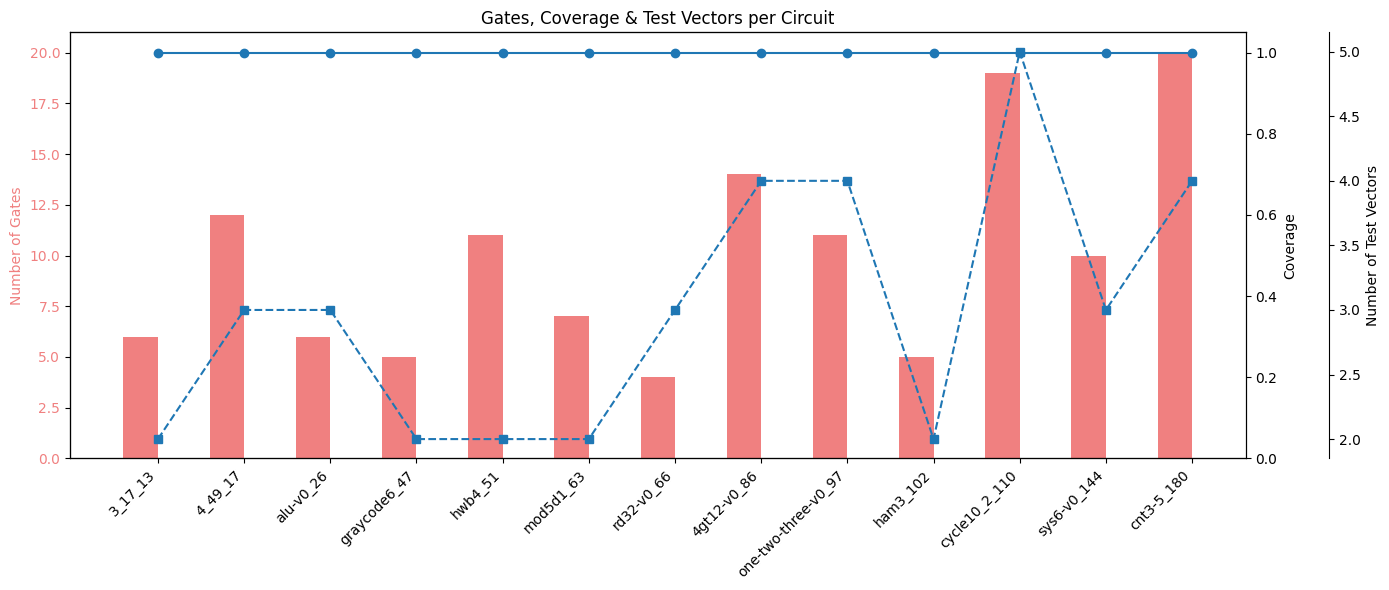

In [18]:
plot_gates_coverage_vectors(results)


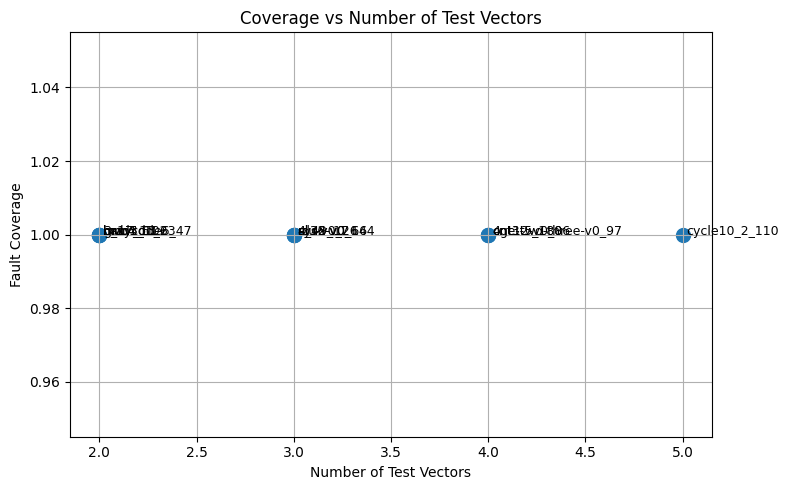

In [19]:
plot_coverage_vs_vectors(results)

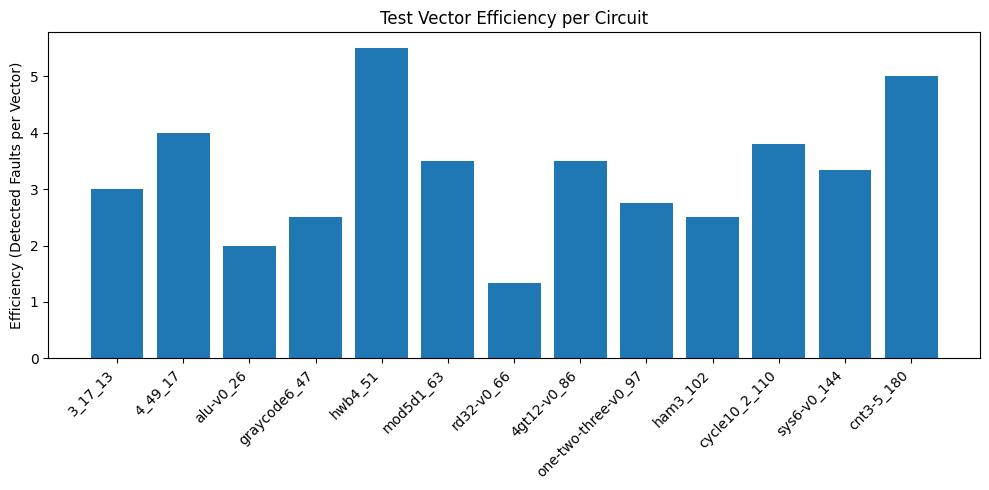

In [20]:
plot_efficiency(results)
# ---------- Example Execution ---------- #


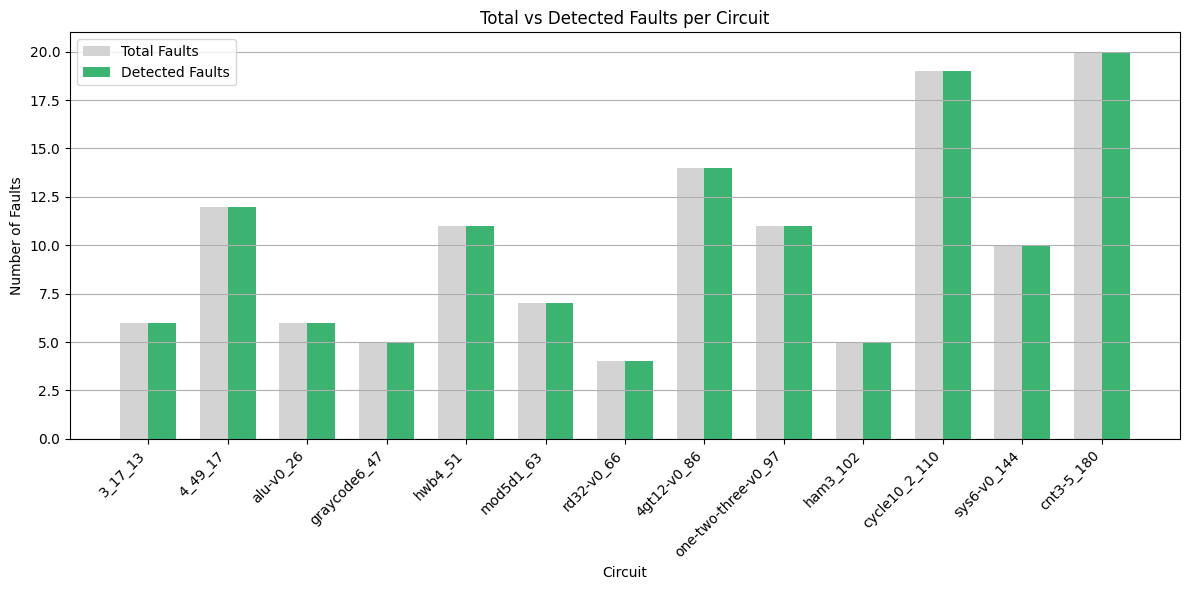

In [21]:
plot_faults_per_circuit(results)
